In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

In [ ]:
data = pd.read_csv("/content/https___www.kaggle.com_datasets_dipam7_student-grade-prediction_resource=download.csv")
data.drop("school", axis=1)

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,6,5,6,6
1,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,4,5,5,6
2,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,10,7,8,10
3,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,2,15,14,15
4,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,M,20,U,LE3,A,2,2,services,services,course,...,5,5,4,4,5,4,11,9,9,9
391,M,17,U,LE3,T,3,1,services,services,course,...,2,4,5,3,4,2,3,14,16,16
392,M,21,R,GT3,T,1,1,other,other,course,...,5,5,3,3,3,3,3,10,8,7
393,M,18,R,LE3,T,3,2,services,other,course,...,4,4,1,3,4,5,0,11,12,10


In [ ]:
data.describe()

,UNIT_NUM,STUB_NAME_NUM,STUB_LABEL_NUM,YEAR,YEAR_NUM,AGE_NUM,ESTIMATE
count,6390.000000,6390.000000,6390.000000,6390.000000,6390.000000,6390.000000,5484.000000
mean,1.872926,4.621909,4.686775,1997.525822,22.692019,2.712207,13.709810
std,0.333081,2.031777,1.829624,14.937451,12.286033,1.932280,11.531805
min,1.000000,0.000000,0.000000,1950.000000,1.000000,0.000000,0.300000
25%,2.000000,3.000000,3.230000,1988.000000,12.000000,0.000000,5.000000
50%,2.000000,5.000000,5.125100,1999.000000,23.000000,3.000000,10.500000
75%,2.000000,6.000000,6.153000,2009.000000,33.000000,4.100000,19.500000
max,2.000000,11.000000,7.235000,2018.000000,42.000000,6.000000,74.800000


# **linear regression is a graph that shows relationship between two (or more) values, by drawing line that has least total distance to points**

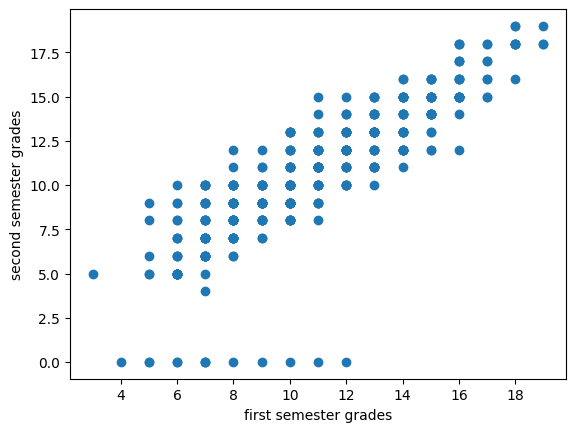

In [ ]:
#LET'S SEE SOME EXAMPLE ON DATASET OF STUDENTS GRADE
#LET'S FIND RELATIONSHIP BETWEEN FIRST SEMESTER GRADES AND SECOND SEMESTER GRADES

x = data["G1"]
y = data["G2"]
plt.scatter(x, y)
plt.xlabel("first semester grades")
plt.ylabel("second semester grades")
plt.show()

**WE CAN CLEARLY SEE THAT GRADES IN FIRST SEMESTER AND GRADES IN SECOND ARE POSITIVELY CORRELATED WITH EACH OTHER**

**IT MEANS THAT, IF YOU GOT GOOD GRADES IN FIRST SEMESTER, YOU HAVE VERY BIG CHANCE TO GET GOOD GRADES IN SECOND ALSO**

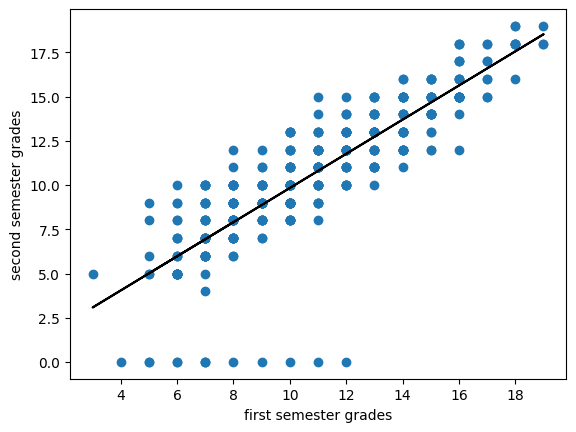

In [ ]:
#NOW LET'S DRAW LINE THAT HAS LEAST AMOUNT OF TOTAL DISTANCE TO POINTS

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

plt.scatter(x, y)
plt.plot(x, mymodel, color = "black")
plt.xlabel("first semester grades")
plt.ylabel("second semester grades")
plt.show()

**THIS LINE GIVES GOOD UNDERSTANDING TO HOW WELL THAY ARE CORRELATED LINEARLY**

# NOW LET'S SEE WHAT IS REGRESSION TABLE

In [ ]:
model = smf.ols("G1 ~ G2", data = data)
results = model.fit()
print(results.summary())

NameError: name 'smf' is not defined

this is linear regression table that gives a lot of information about how two columns correlated

**regression info - top left part of table**

*   Dep. Variable is stands for Dependent Variable, and shows what value is taken to correlate with
*   Model - OLS is short for Ordinary Least Squares. This is a type of model that uses the Least Square method.
*Date: and Time: shows the date and time the output was calculated in Python.
*No. Observations shows how many calculations were done (here its 395, because 395 values of G1 were correlated with 395 values of G2



**Coef is short for coefficient. It is the output of the linear regression function.**


*   Intercept value means how much defference between variables
*   and second line means that if G2 increases by 1, G1 increases by 0.7519

**in other words we can say that G1 is defined by function:**


*   G1 = 0.7519 * G2 + 2.8529


In [ ]:
#LET'S CHECK IT
def predict(x):
  return(0.7519 * x + 2.8529)
print(predict(17.5))

16.01115


it means that, in **average**, grades in first semester of students, who got 17.5 in second, was 16.01115

# **A LITTLE BIT RIGHTER FROM COEFFICIENTS**

*   std err stands for Standard Error
*t is the "t-value" of the coefficients
*P>|t| is called the "P-value"
*[0.025  0.975] represents the confidence interval of the coefficients



**P-VALUE**
The P-value is a statistical number to conclude if there is a relationship between Average_Pulse and Calorie_Burnage.

* A low P-value (< 0.05) means that the coefficient is likely not to equal zero.
* A high P-value (> 0.05) means that we cannot conclude that the explanatory variable affects the dependent variable (here: if Average_Pulse affects Calorie_Burnage).

since in our example it's equal to zero, it means they are definitely correlated

# **R-squared**
R-Squared and Adjusted R-Squared describes how well the linear regression model fits the data points

The value of R-Squared is always between 0 to 1 (0% to 100%).

* A high R-Squared value means that many data points are close to the linear regression function line.
* A low R-Squared value means that the linear regression function line does not fit the data well.

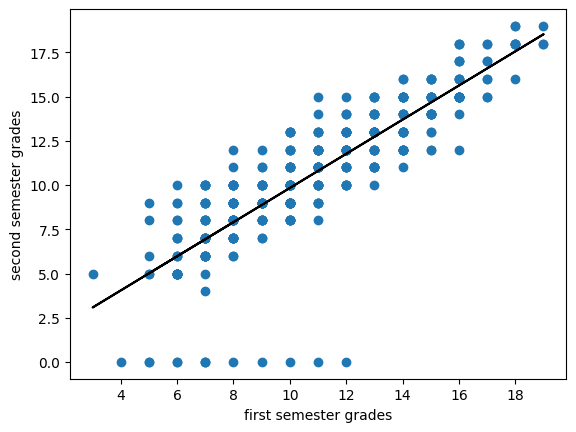

In [ ]:
slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

plt.scatter(x, y)
plt.plot(x, mymodel, color = "black")
plt.xlabel("first semester grades")
plt.ylabel("second semester grades")
plt.show()

We see that a lot of points are not so far away from the line, so R-squared value is high

# In conclusion we can say that regression table really good tool to understand correlation between variables